# Vacant Lot Visualizations (nyc_buildings)

Produces:
- `vacant_parcels_v2.gpkg` — filtered parcel layer for QGIS
- `vacant_lots_map_v2.tif` — RGB chloropleth in EPSG:32618
- `naip_filtered_nyc.vrt` — NAIP VRT filtered to `cfg.naip.year` tiles
- `vacant_lot_samples.png` — thumbnail panel (after QGIS BBL selection)

In [ ]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt

sys.path.append("..")
from vacant_lot.config import load_config
from vacant_lot.data_utils import load_gdb
from vacant_lot.plotting import plot_naip_aoi_figure, save_figure

cfg = load_config("nyc_buildings.yaml")
cfg.ensure_output_dirs()

MAP_LAYERS_DIR = cfg.get_output_dir() / "map_layers"
MAP_LAYERS_DIR.mkdir(parents=True, exist_ok=True)

GPKG_PATH   = MAP_LAYERS_DIR / "vacant_parcels.gpkg"
CHLOROPLETH = MAP_LAYERS_DIR / "vacant_lots_map.tif"
NAIP_VRT    = cfg.get_naip_vrt_path()

print(f"Output dir:      {cfg.get_output_dir()}")
print(f"NAIP VRT:        {NAIP_VRT}")
print(f"GPKG:            {GPKG_PATH}")
print(f"Chloropleth:     {CHLOROPLETH}")
assert NAIP_VRT.exists(), f"VRT not found — run data_prep/01_prepare_segmentation_data.ipynb first"

# Load MapPluto GDB and Make Vacant Mask using BldgClss

In [ ]:
gdf = load_gdb(cfg.get_parcel_path(), layer=cfg.parcel.layer)
gdf = gdf.to_crs(cfg.raster.output_crs)  

vacant_mask = gdf[cfg.parcel.landuse_column].isin(cfg.parcel.vacant_codes)
print(f"Loaded {len(gdf):,} parcels — {vacant_mask.sum():,} vacant ({vacant_mask.mean()*100:.1f}%)")

Loaded 856,998 parcels — 30,792 vacant (3.6%)


# Create vacant_parcels gpkg to easily reference BBL's in QGIS

In [ ]:
keep_cols = [cfg.parcel.id_column, cfg.parcel.landuse_column, "geometry"]
export_gdf = gdf[[c for c in keep_cols if c in gdf.columns]].copy()
export_gdf["is_vacant"] = vacant_mask.astype(int)  # 1 = vacant, 0 = not vacant

export_gdf.to_file(GPKG_PATH, driver="GPKG")
print(f"Saved {len(export_gdf):,} parcels ({vacant_mask.sum():,} vacant) → {GPKG_PATH}")
print("In QGIS: style by 'is_vacant' — fill vacant (1), outline-only for non-vacant (0)")

# Make Chloropleth Map of Vacant Lots 

(time intensive so commented out)

In [ ]:
# import numpy as np
# import rasterio 
# from rasterio.features import rasterize
# from rasterio.transform import from_bounds

# RESOLUTION = 2  # meters (EPSG:26918 units)

# minx, miny, maxx, maxy = gdf.total_bounds
# width  = int((maxx - minx) / RESOLUTION)
# height = int((maxy - miny) / RESOLUTION)
# transform = from_bounds(minx, miny, maxx, maxy, width, height)

# shapes = (
#     [(geom, 1) for geom in gdf[~vacant_mask].geometry if geom is not None]
#   + [(geom, 2) for geom in gdf[vacant_mask].geometry  if geom is not None]
# )

# class_raster = rasterize(shapes, out_shape=(height, width),
#                           transform=transform, fill=0, dtype=np.uint8)

# PALETTE = np.array([
#     [ 26,  26,  46],   # 0 — background (dark navy)
#     [155, 107, 155],   # 1 — non-vacant (mauve purple)
#     [255, 224,  38],   # 2 — vacant (bright yellow)
# ], dtype=np.uint8)

# rgb = PALETTE[class_raster]

# with rasterio.open(CHLOROPLETH, "w", driver="GTiff",
#                    height=height, width=width, count=3,
#                    dtype=np.uint8, crs=cfg.raster.output_crs,
#                    transform=transform, compress="lzw") as dst:
#     dst.write(rgb[:,:,0], 1)
#     dst.write(rgb[:,:,1], 2)
#     dst.write(rgb[:,:,2], 3)

# print(f"Chloropleth written: {CHLOROPLETH}  ({width}×{height} px)")

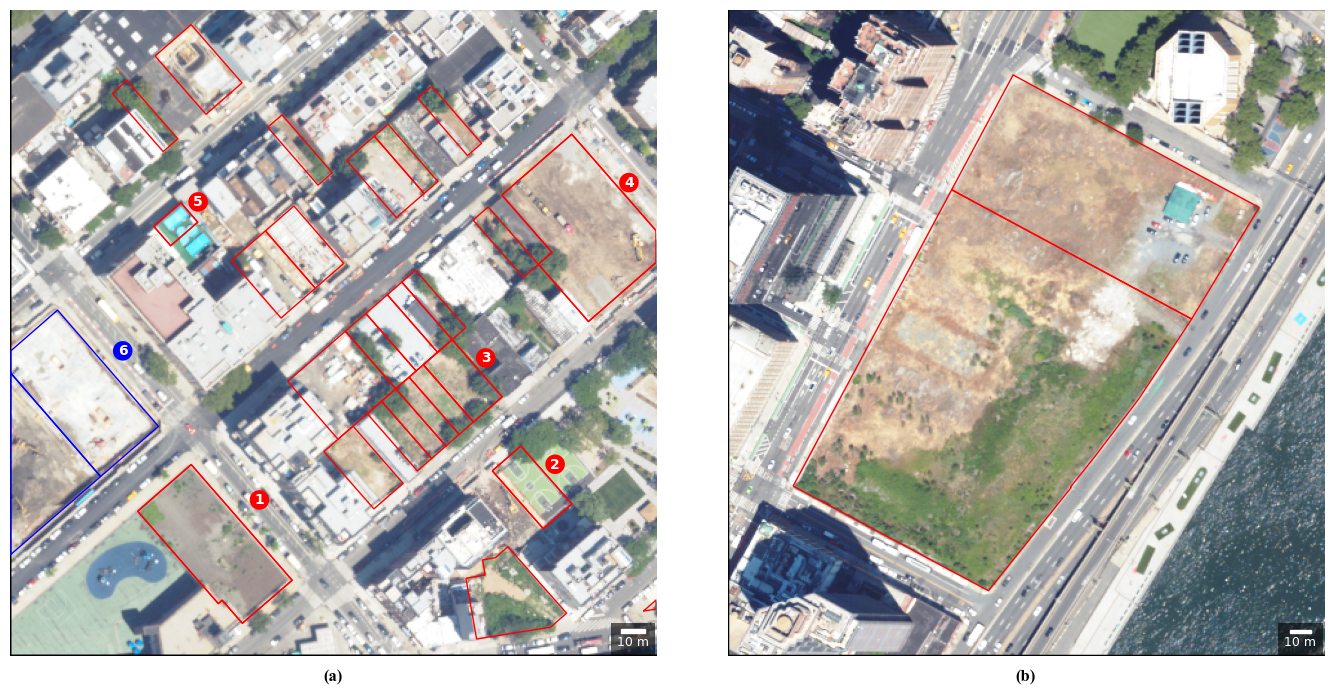

In [ ]:
VACANT_BBLS          = [3022660010, 3022720011, 3022680002, 3022690045, 3022690025]
NON_VACANT_LABELED   = [3022650014]
NON_VACANT_UNLABELED = [3022650016]
HIGHLIGHT_BBLS       = [1009700001, 1009700002]

fig = plot_naip_aoi_figure(
    naip_vrt=NAIP_VRT,
    export_gdf=export_gdf,
    id_column=cfg.parcel.id_column,
    # Panel (a)
    cx=588920.5, cy=4506140.0, radius=130,
    vacant_bbls=VACANT_BBLS,
    non_vacant_labeled_bbls=NON_VACANT_LABELED,
    non_vacant_unlabeled_bbls=NON_VACANT_UNLABELED,
    # Panel (b)
    highlight_bbls=HIGHLIGHT_BBLS,
    pad=30,
)
plt.show()

In [ ]:
# Run this cell to save the figure after inspecting it above
save_figure(fig, cfg.get_final_figures_dir() / "manual_inspection_of_vacant_lots.png")